<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/bank-additional-full (3) (1).csv")

In [ ]:
#sep=";" just tells pandas “my data uses semicolons instead of commas to separate columns.”
df

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."
...,...
41194,"74;""retired"";""married"";""professional.course"";""..."
41195,"74;NA;""married"";""professional.course"";""no"";""ye..."
41196,"74;""retired"";""married"";NA;""no"";""yes"";""no"";""cel..."
41197,NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;N...


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/bank-additional-full (3) (1).csv",sep = ";")

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#show all the column
pd.set_option("display.max_columns",None)
## Show all rows (if you also want all rows)
#pd.set_option("display.max_rows", None)

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,151.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,239.0,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,239.0,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,239.0,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
df.shape

(41199, 21)

In [ ]:
df.isnull().sum().sum()

np.int64(76)

30 percent,10 percent  
at certain cases it is based on size of the data  
if the size of the data is huge then we can remove the null values  
whenever we are haviung more than 30% null values in the data you cant remov ethe null values

In [ ]:
#remove null value
#s you are having more null values and less data size then the optimalmchoice is to replac ethe datas with mean/median/mode
df.dropna(inplace=True)

In [ ]:
df.shape

(41190, 21)

In [ ]:
41199-41190

9

In [ ]:
df.duplicated().sum()

np.int64(13)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

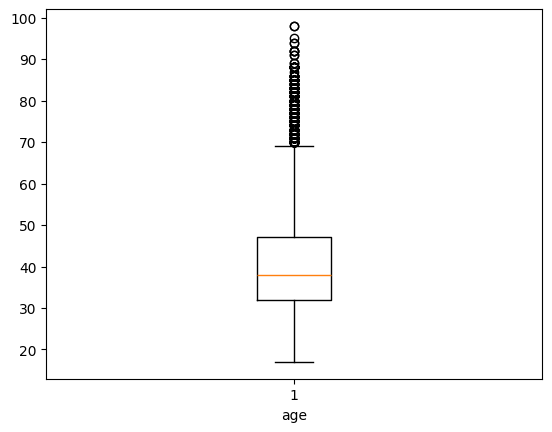

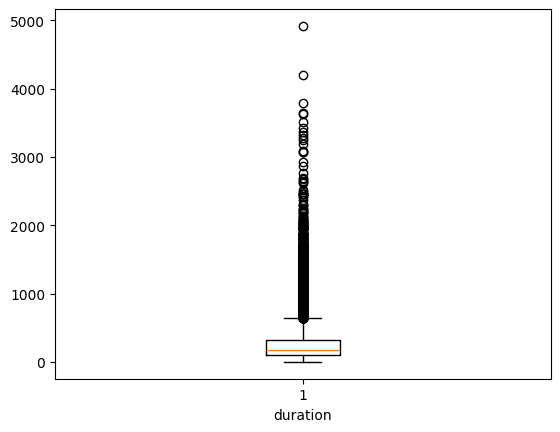

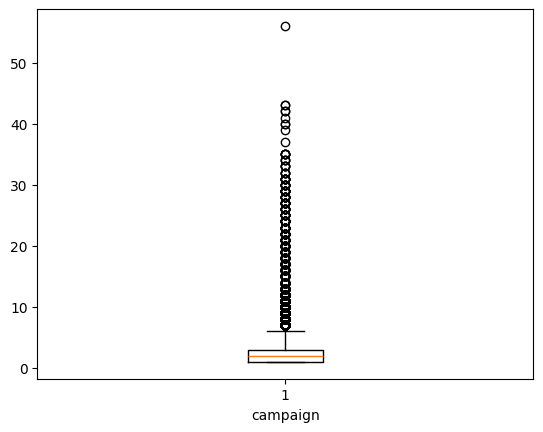

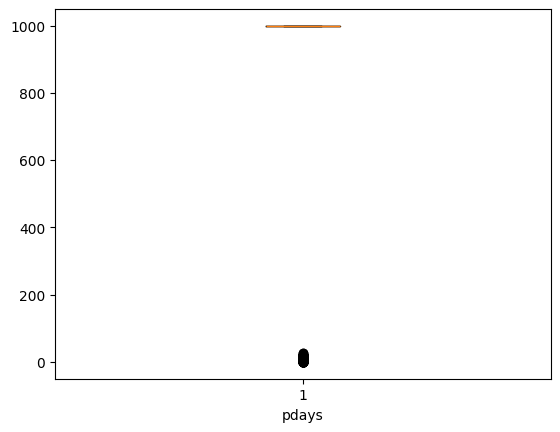

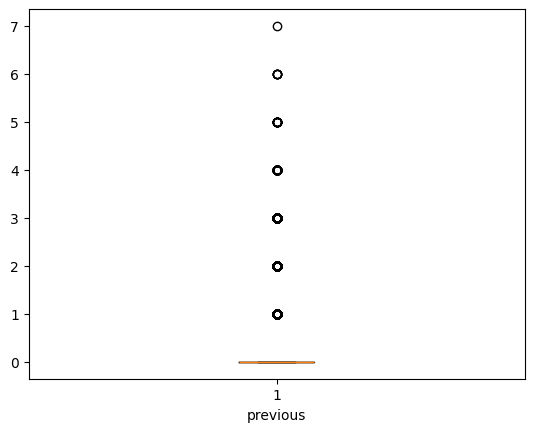

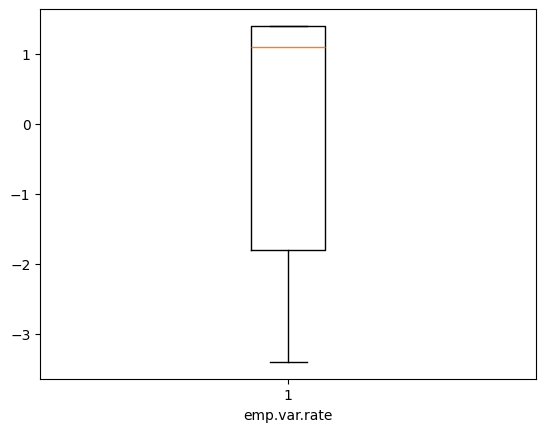

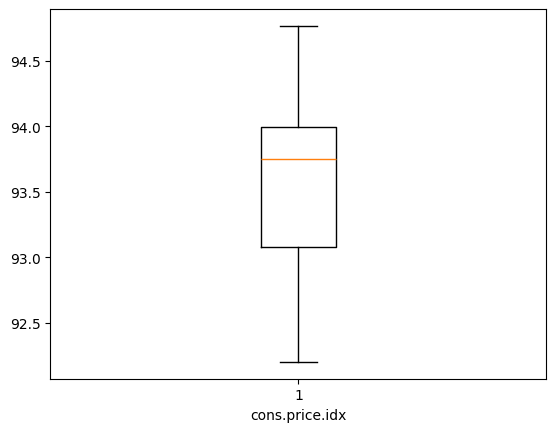

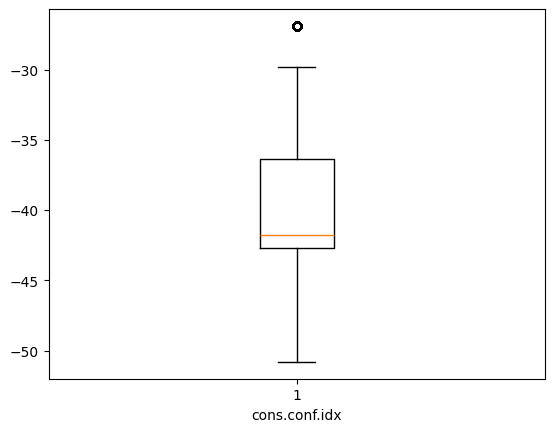

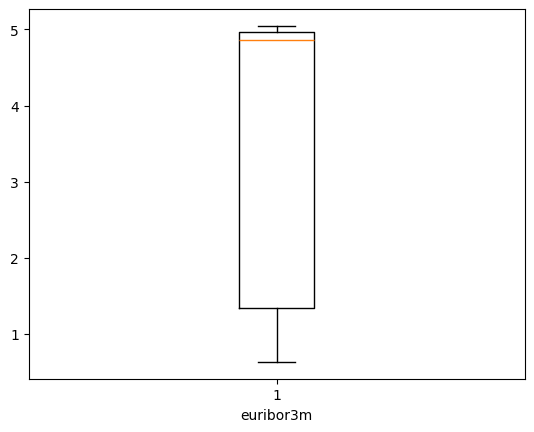

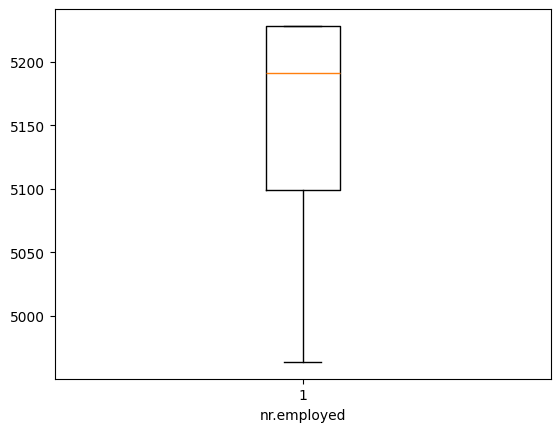

In [ ]:
#outliers
for i in df.columns:
  if df[i].dtype != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
#label encoding
from sklearn.preprocessing import LabelEncoder
label_mapping = {}
for i in df.columns:
  if df[i].dtype == "object":
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])
    label_mapping[i] = dict(zip(le.classes_,le.transform(le.classes_)))
for column, mapping in  label_mapping.items():
  print(f"mapping for {column} : {mapping}")


mapping for job : {'admin.': np.int64(0), 'blue-collar': np.int64(1), 'entrepreneur': np.int64(2), 'housemaid': np.int64(3), 'management': np.int64(4), 'retired': np.int64(5), 'self-employed': np.int64(6), 'services': np.int64(7), 'student': np.int64(8), 'technician': np.int64(9), 'unemployed': np.int64(10), 'unknown': np.int64(11)}
mapping for marital : {'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2), 'unknown': np.int64(3)}
mapping for education : {'basic.4y': np.int64(0), 'basic.6y': np.int64(1), 'basic.9y': np.int64(2), 'high.school': np.int64(3), 'illiterate': np.int64(4), 'professional.course': np.int64(5), 'university.degree': np.int64(6), 'unknown': np.int64(7)}
mapping for default : {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
mapping for housing : {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
mapping for loan : {'no': np.int64(0), 'unknown': np.int64(1), 'yes': np.int64(2)}
mapping for contact : {'cellular': np.int6

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
X = df.drop(columns =['y'])
y=df['y']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size = 0.7,random_state = 142)

In [ ]:
my_model = LogisticRegression()

In [ ]:
my_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = my_model.predict(x_test)

## **Multiclass Classification/Multinomial Logistic Regression/Softmax Regression**

We will use iris dataset for this.because in iris dataset there is three dataset setosa,vercicolor and vrginica

In [ ]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head() #4 inpput column # species is output column

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df['species'].value_counts() #so 3 classes is there in species

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
#we will do label encoder on species column to convert it into numeric
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [ ]:
df['species'].value_counts() #so its changes from string to numeric

,count
species,
0,50
1,50
2,50


In [ ]:
#out of 5 column we will select three column for visualization purpose. you can take all
df = df[['sepal_length','petal_length','species']]

In [ ]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=52)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial') #we will pass parameter multinomial so that sikit learn can get to know that you want to perform softmax regression

In [ ]:
#train the model
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9333333333333333


In [ ]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,7,0,0
1,0,8,1
2,0,1,13


In [ ]:
#now to check the prediction we will pass a query
query = np.array([[3.4,2.7]]) #3.4 is sepal length input and 2.7 is petal length input

In [ ]:
#predict proba means predict probability function kya karega wo softmax ka output batayega for each of the classes basically 3 (0,1,2) class ka honeka probability batayega
model.predict_proba(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[8.22508581e-01, 1.77042920e-01, 4.48498788e-04]])

array([[8.22508581e-01, 1.77042920e-01, 4.48498788e-04]])  
8.22508581e-01 = class ke setosa honeki probability  
1.77042920e-01 = versicolor honeki probability  
4.48498788e-04 = virginica hineki probability  
when you add 3 number 8.22508581e-01, 1.77042920e-01, 4.48498788e-04 you will get 1 always

In [ ]:
#jab predict function lagayenge tab jo max value from that three numbers you will get that one
model.predict(query) #result array([0]) means setosa

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


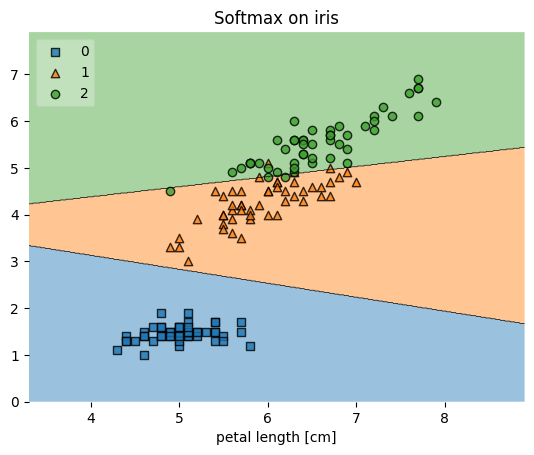

In [ ]:
#visualization
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values,y.values,model,legend = 2)

#adding axis annotation
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on iris')

plt.show() #so here we can see that logistic regression can classify three different classes(here 3 different region we are getting)

try to apply on mnist dataset,fist apply pca on dataset then take 2 topproncipal component then apply this..there have 10 classes then you will get 10 alag decision region,here 3 different region we are getting

In [ ]:
!git filter-branch --force --index-filter \
  "git rm --cached --ignore-unmatch Logistic_regression_all_practice.ipynb" \
  --prune-empty --tag-name-filter cat -- --all


	 rewrites.  Hit Ctrl-C before proceeding to abort, then use an
	 alternative filtering tool such as 'git filter-repo'
	 (https://github.com/newren/git-filter-repo/) instead.  See the
	 filter-branch manual page for more details; to squelch this warning,
	 set FILTER_BRANCH_SQUELCH_WARNING=1.
Proceeding with filter-branch...

fatal: Needed a single revision


In [ ]:
!git add Logistic_regression_all_practice.ipynb
!git commit -m "Remove file with leaked token"
!git push origin main --force


fatal: pathspec 'Logistic_regression_all_practice.ipynb' did not match any files
On branch main

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data_science_all/

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Eshachatterjee01/data_science_all'
